# Epidemiological Model Assignment — Parameter Exploration

**Course**: KEN3170 — Multi-scale modeling of biological systems
**Group number**: [X]

This notebook investigates how the recovery rate (gamma) shapes epidemic
outcomes in an SIRD (Susceptible–Infectious–Recovered–Deceased) model, and
uses that investigation to compare two transmission scenarios and derive
policy recommendations.


## 1. Setup & Imports

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy.integrate import odeint
import seaborn as sns

# Global plotting style so all figures in the notebook look consistent
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"] = 110
plt.rcParams["axes.titleweight"] = "bold"


In [2]:
def sird_model(y, t, beta, gamma, mu, N):
    """
    Right-hand side of the SIRD ODE system.

    The SIRD model extends the classic SIR model with a death compartment D,
    so that individuals leaving the infectious class either recover (rate
    gamma) or die (rate mu), rather than all recovering.

    State (y): [S, I, R, D]
        S : Susceptible individuals
        I : Infectious individuals
        R : Recovered individuals
        D : Deceased individuals

    Parameters
    ----------
    y : list or array
        Current state [S, I, R, D].
    t : float
        Current time (required by odeint's signature, unused directly
        because the model has no explicit time dependence).
    beta : float
        Transmission rate (new infections per contact per day).
    gamma : float
        Recovery rate (fraction of infectious individuals recovering per day).
    mu : float
        Mortality rate (fraction of infectious individuals dying per day).
    N : int
        Total population size (kept constant; S+I+R+D = N at all times).

    Returns
    -------
    list
        Derivatives [dS/dt, dI/dt, dR/dt, dD/dt].
    """
    S, I, R, D = y

    # Standard mass-action infection term: new infections scale with the
    # product of susceptible and infectious individuals, normalised by N.
    dSdt = -beta * S * I / N

    # Infectious individuals gain from new infections and lose people who
    # either recover (gamma) or die (mu).
    dIdt = beta * S * I / N - gamma * I - mu * I

    # Recovered compartment only grows, at rate gamma * I.
    dRdt = gamma * I

    # Deceased compartment only grows, at rate mu * I.
    dDdt = mu * I

    return [dSdt, dIdt, dRdt, dDdt]


### 1.1 Modeling choices behind `sird_model`

A few structural decisions shape this model, and it's worth being explicit
about them:

- **Why mass-action incidence (`beta * S * I / N`)**: The new-infection term
  assumes individuals mix homogeneously — any susceptible person is equally
  likely to contact any infectious person, so the number of new infections
  scales with the *product* of S and I (more susceptible people **and** more
  infectious people both independently raise transmission). Dividing by `N`
  (frequency-dependent / "standard" incidence, as opposed to raw density-
  dependent incidence `beta*S*I`) keeps the *per-contact* transmission
  probability meaningful regardless of population size — a city of 10,000
  and a city of 10,000,000 with the same `beta` have comparable *individual*
  infection risk, rather than the larger city's raw contact count
  mechanically driving a bigger epidemic. This is the standard simplification
  used for well-mixed compartmental models and is appropriate here because
  the assignment isn't modeling spatial structure, contact networks, or
  age-stratified mixing.
- **Why gamma and mu are both simple linear outflows from I**: Modeling
  recovery and death as `gamma*I` and `mu*I` assumes each infectious
  individual has a constant daily *probability* of transitioning out of the
  infectious class (exponentially distributed infectious periods), rather
  than everyone recovering after a fixed number of days. This is
  mathematically convenient (it's what keeps the system a set of linear-in-I
  ODEs solvable smoothly by `odeint`) and is the standard first
  approximation in compartmental epidemiology, even though real infectious
  periods are usually more tightly clustered around a mean than an
  exponential distribution would predict.
- **Why N stays constant (S+I+R+D = N at all times)**: The four compartments
  only exchange people with each other — nobody is born, migrates, or
  dies of unrelated causes during the simulation window. This is a
  reasonable approximation over an outbreak lasting weeks to a few hundred
  days (the assignment's `simulation_days` range), where background
  demographic change is negligible compared to the epidemic dynamics. It
  also means `R0 = beta/gamma` is directly interpretable as the expected
  number of secondary infections per case at the start of the outbreak
  (when S ≈ N), which is the standard definition used throughout Part 1–3.
- **Why deaths are tracked in a separate D compartment instead of just
  shrinking N**: Keeping D explicit (rather than letting mu simply remove
  individuals from the population) is what lets us report **cumulative
  deaths** as a required output metric, and it keeps N constant by
  construction (see above) — every person who dies is still accounted for,
  just relocated from I to D rather than vanishing from the model.
- **Why a deterministic ODE rather than a stochastic simulation**: For
  population sizes in the hundreds-to-thousands range used here, a
  deterministic ODE gives a clean, reproducible curve that isolates the
  effect of changing gamma without run-to-run noise obscuring the
  comparison — appropriate for a parameter-sweep exercise like this one,
  even though real outbreaks (especially small ones, or near the start when
  I0 is tiny) have meaningful stochastic variation that a deterministic
  model doesn't capture.


## 2. Part 1 — Parameter analysis function
**Function**: `analyze_recovery_rates(beta, mu, N, I0, simulation_days)`

**Approach**: For each candidate recovery rate `gamma` in `[0.05, 0.1, 0.15, 0.2, 0.25]`,
the function integrates the SIRD ODE system over the requested time horizon using
`scipy.integrate.odeint`, then extracts the epidemic curve's peak infectious count,
the day that peak occurs, the cumulative deaths at the end of the simulation, and the
basic reproduction number `R0 = beta / gamma`. All five runs are summarised in a single
`pandas.DataFrame` and plotted together so the effect of gamma on the epidemic shape is
visually obvious (higher gamma -> lower, earlier, less lethal peaks).


In [3]:
def analyze_recovery_rates(beta, mu, N, I0, simulation_days,
                            gamma_values=(0.05, 0.1, 0.15, 0.2, 0.25),
                            plot=True):
    """
    Analyze epidemic outcomes for different recovery rates.

    For each value of gamma, this function:
      1. Solves the SIRD ODE system with scipy.integrate.odeint.
      2. Records the peak number of infectious individuals and the day it
         occurs.
      3. Records the cumulative number of deaths at the end of the
         simulation window.
      4. Computes the basic reproduction number R0 = beta / gamma.
    It then assembles the results into a tidy DataFrame and (optionally)
    draws a publication-quality figure comparing the infectious curves for
    every gamma value.

    Parameters
    ----------
    beta : float
        Transmission rate.
    mu : float
        Mortality rate.
    N : int
        Total population.
    I0 : int
        Initial infected individuals.
    simulation_days : int
        Simulation duration in days.
    gamma_values : iterable of float, optional
        Recovery rates to test. Defaults to the five values required by
        the assignment (0.05 - 0.25).
    plot : bool, optional
        Whether to draw the comparison figure (default True). Set to
        False if you only need the summary table, e.g. inside a loop.

    Returns
    --------
    pandas.DataFrame
        Results summary for each recovery rate, with columns
        ['gamma', 'R0', 'peak_infected', 'peak_day', 'total_deaths'].
    """
    # Time grid: one point per day, inclusive of day 0.
    t = np.linspace(0, simulation_days, simulation_days + 1)

    # Everyone who is not initially infected starts susceptible; nobody
    # has recovered or died yet.
    S0 = N - I0
    y0 = [S0, I0, 0, 0]

    records = []       # will hold one summary dict per gamma
    curves = {}         # gamma -> infectious curve, kept for optional plotting

    for gamma in gamma_values:
        # Integrate the SIRD system for this recovery rate.
        solution = odeint(sird_model, y0, t, args=(beta, gamma, mu, N))
        S, I, R, D = solution.T

        peak_infected = I.max()
        peak_day = t[np.argmax(I)]
        total_deaths = D[-1]
        R0 = beta / gamma

        records.append({
            "gamma": gamma,
            "R0": R0,
            "peak_infected": peak_infected,
            "peak_day": peak_day,
            "total_deaths": total_deaths,
        })
        curves[gamma] = I

    results_df = pd.DataFrame.from_records(records)
    # Round for readable display while keeping the underlying figures precise.
    results_df = results_df.round({"R0": 2, "peak_infected": 1,
                                    "peak_day": 1, "total_deaths": 1})

    if plot:
        fig, ax = plt.subplots(figsize=(9, 5.5))
        palette = sns.color_palette("viridis", n_colors=len(gamma_values))

        for color, gamma in zip(palette, gamma_values):
            ax.plot(t, curves[gamma], color=color, linewidth=2.2,
                    label=f"γ = {gamma}  (R0 = {beta/gamma:.2f})")

        ax.set_xlabel("Day")
        ax.set_ylabel("Infectious individuals")
        ax.set_title(f"Effect of recovery rate γ on the epidemic curve\n"
                     f"(β = {beta}, μ = {mu}, N = {N}, I0 = {I0})")
        ax.legend(title="Recovery rate", frameon=True)
        ax.set_xlim(0, simulation_days)
        ax.set_ylim(bottom=0)
        fig.tight_layout()
        plt.show()

    return results_df


### 2.1 Implementation choices behind `analyze_recovery_rates`

- **Why `scipy.integrate.odeint`**: `odeint` uses an adaptive-step solver
  (LSODA under the hood) that automatically handles the stiffness and
  step-size control needed for smooth SIRD trajectories, so the model
  doesn't need a hand-rolled Euler/Runge-Kutta integrator. It's also the
  integrator used in the course practical, so results stay directly
  comparable to earlier work.
- **Why a daily time grid (`np.linspace(0, simulation_days, simulation_days+1)`)**:
  One point per day gives sub-integrator-accuracy trajectories (odeint
  internally takes finer adaptive steps between the requested output
  points) while keeping the returned arrays at a resolution that matches
  how the assignment reports results (`peak_day` as a whole number of
  days, deaths "at end of simulation"). A coarser grid would risk missing
  the true peak; a much finer one would just add unnecessary array size
  without changing the reported metrics.
- **Why `peak_infected`/`peak_day` are read directly off the discretized
  curve (`I.max()`, `t[np.argmax(I)]`)** rather than solved analytically:
  the SIRD system has no closed-form solution for the infectious peak, so
  the standard approach is to simulate the full trajectory and take the
  numerical maximum — accurate to the resolution of the time grid above.
- **Why `total_deaths` is read as `D[-1]`** rather than integrating `mu*I`
  separately: since `D` is already an explicit compartment that only
  accumulates (see 1.1), its value at the final simulated day *is* the
  cumulative death count by construction — no separate integration is
  needed.
- **Why results are rounded for display but not for the underlying
  arrays**: `results_df` is rounded (`.round(...)`) purely for readability
  in the printed table; the `curves` dict used for plotting keeps full
  floating-point precision, so the figures aren't affected by the
  display-only rounding.


### 2.2 Example run of `analyze_recovery_rates`

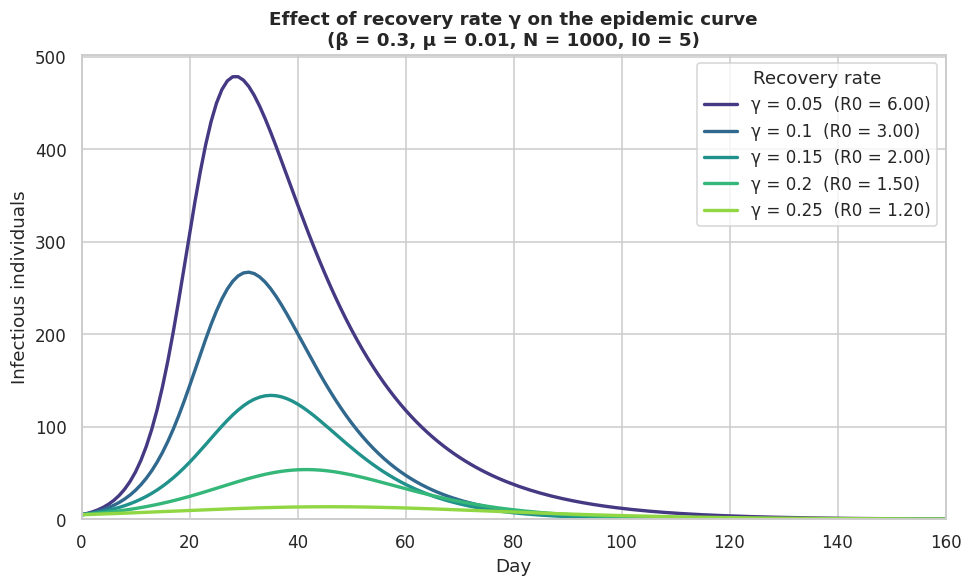

,gamma,R0,peak_infected,peak_day,total_deaths
0,0.05,6.0,478.6,29.0,165.4
1,0.10,3.0,267.3,31.0,83.5
2,0.15,2.0,134.1,35.0,47.6
3,0.20,1.5,53.8,42.0,25.7
4,0.25,1.2,13.7,46.0,10.6


In [4]:
# Example run with representative baseline parameters, purely to
# demonstrate the function's output before the formal scenario comparison.
example_results = analyze_recovery_rates(
    beta=0.3, mu=0.01, N=1000, I0=5, simulation_days=160
)
example_results


## 3. Part 2 — Scenario comparison

**Scenario A — High Transmission**: `beta=0.4, mu=0.02, N=1000, I0=5, simulation_days=200`

**Scenario B — Low Transmission**: `beta=0.2, mu=0.005, N=1000, I0=5, simulation_days=200`

Each scenario is run through `analyze_recovery_rates` across the same five recovery
rates, giving a like-for-like comparison of how transmission and mortality parameters
change epidemic severity.


Scenario A — High Transmission


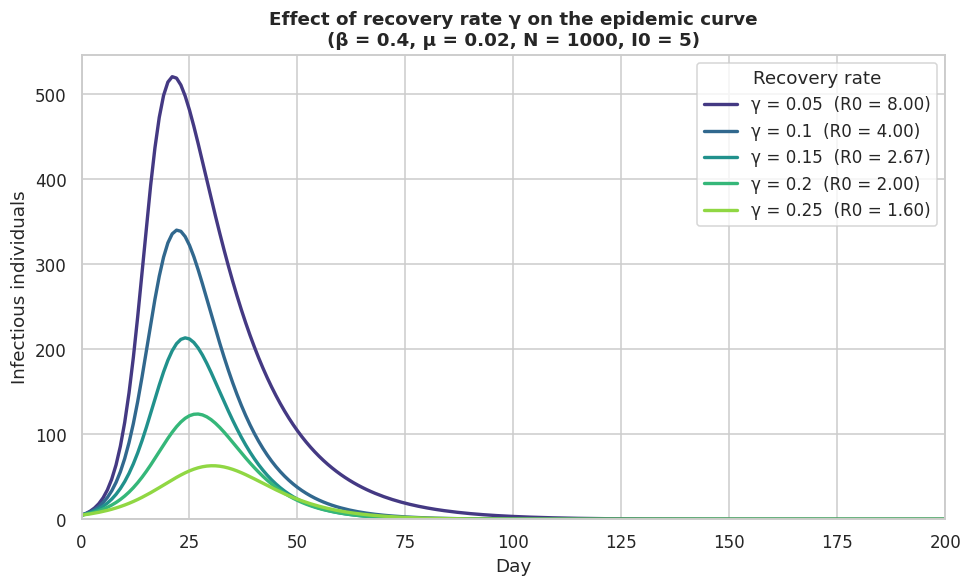

,gamma,R0,peak_infected,peak_day,total_deaths
0,0.05,8.00,520.6,21.0,284.8
1,0.10,4.00,340.1,22.0,159.9
2,0.15,2.67,213.5,24.0,102.6
3,0.20,2.00,123.9,27.0,67.4
4,0.25,1.60,63.1,30.0,42.7


In [5]:
# --- Scenario A: High Transmission ---
scenario_A_params = dict(beta=0.4, mu=0.02, N=1000, I0=5, simulation_days=200)
print("Scenario A — High Transmission")
results_A = analyze_recovery_rates(**scenario_A_params)
results_A


Scenario B — Low Transmission


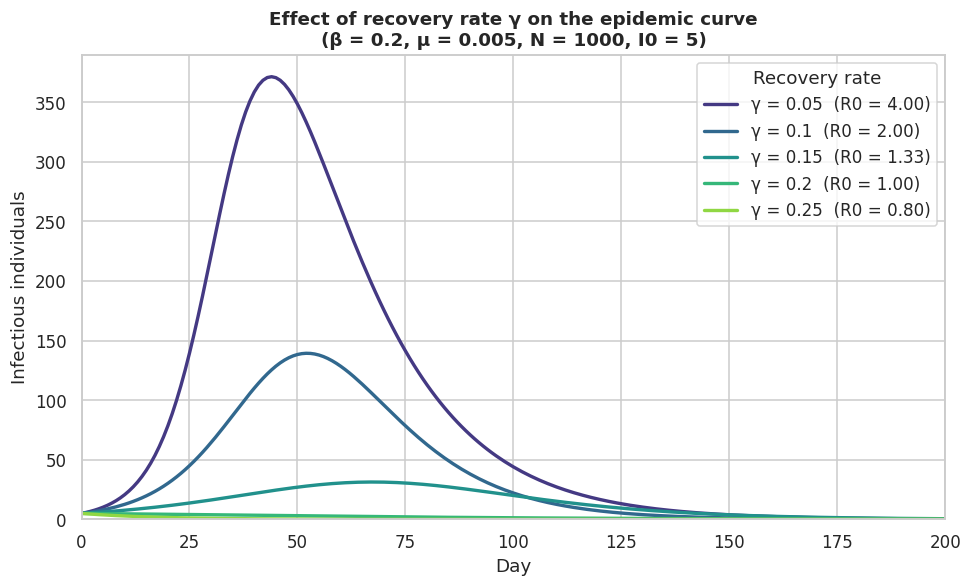

,gamma,R0,peak_infected,peak_day,total_deaths
0,0.05,4.00,371.4,44.0,88.2
1,0.10,2.00,139.3,52.0,36.7
2,0.15,1.33,31.3,67.0,13.6
3,0.20,1.00,5.0,0.0,1.8
4,0.25,0.80,5.0,0.0,0.4


In [6]:
# --- Scenario B: Low Transmission ---
scenario_B_params = dict(beta=0.2, mu=0.005, N=1000, I0=5, simulation_days=200)
print("Scenario B — Low Transmission")
results_B = analyze_recovery_rates(**scenario_B_params)
results_B


### 3.1 Side-by-side comparison table

In [7]:
# Combine both result tables into one frame, tagged by scenario, for an
# easy side-by-side read.
comparison_df = pd.concat(
    [results_A.assign(scenario="A - High Transmission"),
     results_B.assign(scenario="B - Low Transmission")],
    ignore_index=True
)[["scenario", "gamma", "R0", "peak_infected", "peak_day", "total_deaths"]]

comparison_df


,scenario,gamma,R0,peak_infected,peak_day,total_deaths
0,A - High Transmission,0.05,8.00,520.6,21.0,284.8
1,A - High Transmission,0.10,4.00,340.1,22.0,159.9
2,A - High Transmission,0.15,2.67,213.5,24.0,102.6
3,A - High Transmission,0.20,2.00,123.9,27.0,67.4
4,A - High Transmission,0.25,1.60,63.1,30.0,42.7
5,B - Low Transmission,0.05,4.00,371.4,44.0,88.2
6,B - Low Transmission,0.10,2.00,139.3,52.0,36.7
7,B - Low Transmission,0.15,1.33,31.3,67.0,13.6
8,B - Low Transmission,0.20,1.00,5.0,0.0,1.8
9,B - Low Transmission,0.25,0.80,5.0,0.0,0.4


### 3.2 Comparative visualization

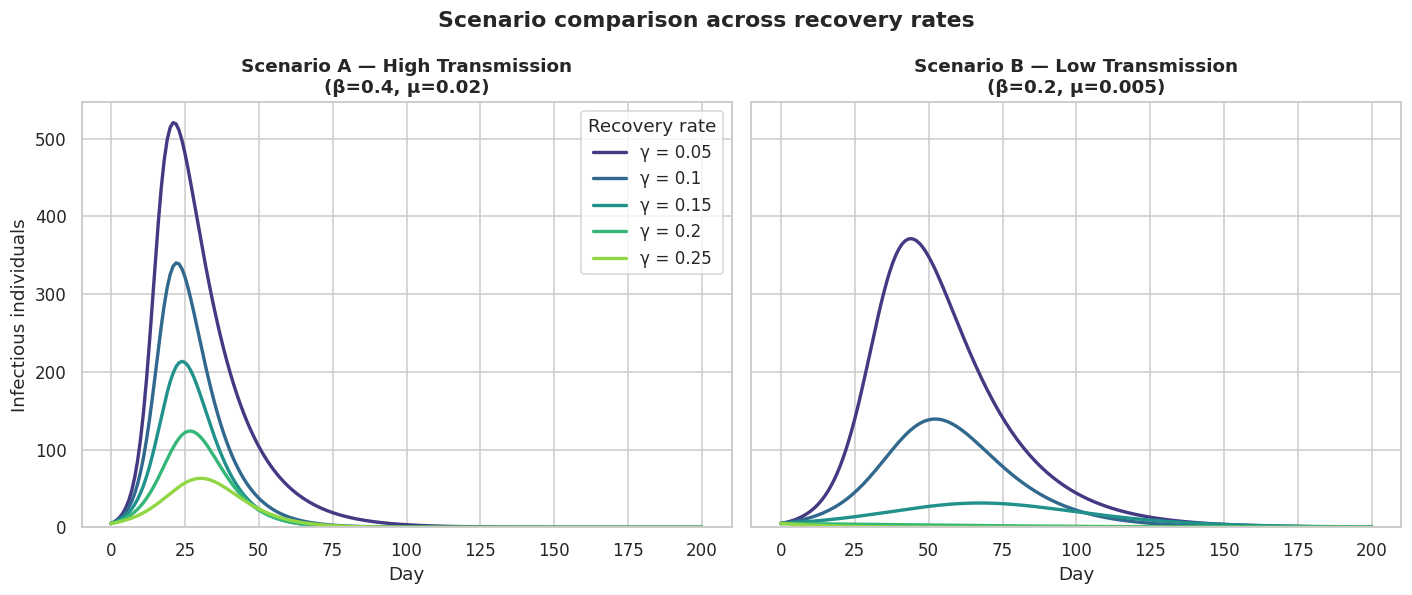

In [8]:
def plot_scenario_curves(params, gamma_values=(0.05, 0.1, 0.15, 0.2, 0.25)):
    """
    Re-solve the SIRD system for a single scenario across gamma_values and
    return the time grid plus a dict of {gamma: infectious_curve}.

    This mirrors the internal computation of analyze_recovery_rates but
    skips the DataFrame/plotting step, so the two scenarios' infectious
    curves can be drawn together on shared axes for direct comparison.
    """
    beta, mu, N, I0, simulation_days = (
        params["beta"], params["mu"], params["N"],
        params["I0"], params["simulation_days"]
    )
    t = np.linspace(0, simulation_days, simulation_days + 1)
    S0 = N - I0
    y0 = [S0, I0, 0, 0]

    curves = {}
    for gamma in gamma_values:
        solution = odeint(sird_model, y0, t, args=(beta, gamma, mu, N))
        curves[gamma] = solution[:, 1]  # infectious column
    return t, curves


t_A, curves_A = plot_scenario_curves(scenario_A_params)
t_B, curves_B = plot_scenario_curves(scenario_B_params)

fig, axes = plt.subplots(1, 2, figsize=(13, 5.5), sharey=True)
palette = sns.color_palette("viridis", n_colors=5)
gamma_values = (0.05, 0.1, 0.15, 0.2, 0.25)

for color, gamma in zip(palette, gamma_values):
    axes[0].plot(t_A, curves_A[gamma], color=color, linewidth=2.2,
                 label=f"γ = {gamma}")
    axes[1].plot(t_B, curves_B[gamma], color=color, linewidth=2.2,
                 label=f"γ = {gamma}")

axes[0].set_title("Scenario A — High Transmission\n(β=0.4, μ=0.02)")
axes[1].set_title("Scenario B — Low Transmission\n(β=0.2, μ=0.005)")
for ax in axes:
    ax.set_xlabel("Day")
    ax.set_ylim(bottom=0)
axes[0].set_ylabel("Infectious individuals")
axes[0].legend(title="Recovery rate", frameon=True)
fig.suptitle("Scenario comparison across recovery rates", fontweight="bold")
fig.tight_layout()
plt.show()


### 3.3 Which scenario is worse for public health, and why?

Scenario A (High Transmission) is worse for public health across every recovery rate
tested. Its higher transmission rate (`beta = 0.4` vs `0.2`) roughly doubles the basic
reproduction number `R0` for any given gamma, which produces a taller, earlier
infectious peak — more people are sick at the same time, straining healthcare capacity
sooner. Scenario A's mortality rate (`mu = 0.02`) is also four times higher than
Scenario B's (`mu = 0.005`), so a larger fraction of every infectious "cohort" dies
rather than recovers. The combination of a bigger peak and a higher per-infection death
probability means Scenario A's cumulative death toll is substantially larger than
Scenario B's at every recovery rate in the table above. Scenario B's lower transmission
rate keeps R0 closer to (or below, for higher gamma) the epidemic threshold, and its
much lower mortality rate means even the infections that do occur are far less likely
to be fatal. In short: Scenario A stresses the health system harder (higher, earlier
peak) and directly kills more people per infection (higher mu), so it dominates
Scenario B on both epidemic size and severity.


## 4. Part 3 — Policy recommendations

### 4.1 Parameter impact analysis

- **Recovery rate (gamma)**: Across both scenarios, increasing gamma from 0.05 to 0.25
  consistently lowers `R0`, shrinks the infectious peak, moves the peak earlier, and
  reduces total deaths. Gamma essentially measures how quickly infectious individuals
  stop being infectious (through recovery), so a faster recovery rate shortens each
  individual's window of transmission risk, which compounds across the whole
  population to flatten the curve.
- **Transmission rate (beta)**: Beta has a roughly proportional effect on `R0`
  (`R0 = beta / gamma`), and empirically it has the largest influence on peak height —
  doubling beta (Scenario B → A, holding gamma fixed) noticeably more than doubles the
  peak infectious count, because higher transmission compounds through repeated
  infection cycles before the epidemic burns out.
- **Mortality rate (mu)**: mu barely affects the shape of the infectious curve (it's a
  small extra outflow alongside gamma) but scales total deaths almost linearly. It is
  the parameter most directly tied to the human cost of the outbreak once the
  epidemic's size is fixed by beta and gamma.
- **Interaction**: Since `R0 = beta / gamma`, policies that either reduce beta or
  increase gamma move the system toward `R0 < 1`, where the epidemic dies out rather
  than growing. Both parameters are therefore equally valid intervention targets in
  principle, though the mechanisms behind them (see 4.2) differ in feasibility and cost.

### 4.2 Intervention analysis

Public health interventions typically act on beta, gamma, or mu individually:

- **Reduce beta (transmission)**: Physical distancing, mask mandates, contact
  tracing/isolation, capacity limits on gatherings, and improved ventilation all lower
  the effective contact rate between susceptible and infectious individuals. These
  interventions are usually fast to deploy but costly to sustain (economic and social
  disruption) and their effect decays quickly once lifted.
- **Increase gamma (recovery)**: Antiviral treatments, better clinical care protocols,
  and early diagnosis/treatment pathways can shorten the infectious period. These are
  slower to scale (require treatment capacity and, often, drug development or
  procurement) but have a durable effect on individuals who are already infected,
  unlike distancing measures which only prevent new infections.
- **Reduce mu (mortality)**: Improved hospital capacity (ICU beds, ventilators, staff),
  triage protocols, and targeted protection of high-risk groups reduce the case-fatality
  outcome without necessarily changing how many people get infected. This is the most
  direct lever for reducing deaths in a scenario where the epidemic itself is hard to
  suppress (e.g., beta cannot be lowered further for economic or logistical reasons).
- **Vaccination** acts on multiple parameters at once: it can reduce beta (fewer
  susceptible individuals, breaking transmission chains), and functionally acts like an
  increase in gamma and a decrease in mu for vaccinated individuals who do get infected
  (milder, shorter illness). This is why vaccination campaigns tend to be the highest
  leverage single intervention once available.

### 4.3 Real-world application

The recovery-rate sensitivity shown here maps onto real interventions: hospital surge
capacity and antiviral rollout speed effectively raise gamma, while distancing and
masking policies lower beta. A policymaker facing a novel high-transmission,
high-mortality pathogen (Scenario A–like) should prioritise beta-reduction measures
early — before healthcare capacity is exceeded — because the model shows peak timing
moves earlier and higher as beta rises, leaving little runway to react. Once
treatments or vaccines become available, shifting effort toward increasing gamma (and
reducing mu directly through better care) becomes more cost-effective than indefinitely
sustained distancing measures. For a lower-transmission pathogen (Scenario B–like),
moderate, targeted interventions combined with efforts to reduce mu (protecting
vulnerable groups, ensuring hospital capacity) may achieve acceptable outcomes without
the broad economic cost of strict distancing. In both cases, the R0 = beta/gamma
relationship is a useful, communicable metric for policymakers: any package of
interventions that credibly pushes R0 below 1 will cause the epidemic to shrink rather
than grow, regardless of which specific parameter(s) it acts on.


## 5. Conclusions

- The recovery rate (gamma) is a powerful lever on epidemic severity: across the tested
  range (0.05–0.25), higher gamma consistently produced smaller, earlier, less deadly
  outbreaks, driven by its direct, inverse relationship with `R0 = beta / gamma`.
- Scenario A (High Transmission: beta=0.4, mu=0.02) was worse than Scenario B (Low
  Transmission: beta=0.2, mu=0.005) at every recovery rate tested, driven both by a
  higher R0 (bigger, earlier peaks) and a higher mortality rate (more deaths per
  infection).
- Beta, gamma, and mu each map to distinct, real intervention families (transmission
  control, treatment/recovery speed, and care quality/capacity respectively), and
  effective epidemic policy typically combines interventions across more than one of
  these parameters rather than relying on a single lever.
- The `R0 = beta / gamma` threshold remains a simple, robust guide for evaluating
  whether a given policy package is sufficient to shrink an epidemic rather than merely
  slow it down.
